In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
PROC_DIR = Path("../data/processed")

gold = pd.read_csv(PROC_DIR / "gold_annotations.csv", encoding="utf-8-sig")
truth = pd.read_csv(PROC_DIR / "gold_truth.csv")

g = pd.DataFrame({
    "text": gold["text"],
    "human_queue": gold["my_queue"].str.strip(),
    "human_priority": gold["my_priority"].str.strip().str.lower(),
    "data_queue": truth["queue"],
    "data_priority": truth["priority"],
    "note": gold["note"],
})

# guard against typos breaking the analysis
QUEUES = set(truth["queue"].unique())
bad_q = set(g["human_queue"]) - QUEUES
bad_p = set(g["human_priority"]) - {"low", "medium", "high"}
print("Unknown queue labels:", bad_q or "none")
print("Unknown priority labels:", bad_p or "none")
print("Missing annotations:", g[["human_queue", "human_priority"]].isna().sum().sum())
print("\nRows:", len(g))
print("Flagged ambiguous:", g["note"].notna().sum())

Unknown queue labels: none
Unknown priority labels: none
Missing annotations: 0

Rows: 300
Flagged ambiguous: 0


In [2]:
g["queue_agree"] = g["human_queue"] == g["data_queue"]
g["prio_agree"] = g["human_priority"] == g["data_priority"]

print(f"Queue agreement    : {g['queue_agree'].mean():.3f}")
print(f"Priority agreement : {g['prio_agree'].mean():.3f}")
print(f"Both agree         : {(g['queue_agree'] & g['prio_agree']).mean():.3f}")

Queue agreement    : 0.257
Priority agreement : 0.417
Both agree         : 0.127


In [3]:
per_class = (g.groupby("data_queue")
             .agg(n=("queue_agree", "size"),
                  agreement=("queue_agree", "mean"))
             .sort_values("agreement"))
print(per_class.round(3).to_string())

                                  n  agreement
data_queue                                    
Customer Service                 30      0.033
Returns and Exchanges            30      0.033
Product Support                  30      0.100
Human Resources                  30      0.167
Sales and Pre-Sales              30      0.200
General Inquiry                  30      0.267
IT Support                       30      0.267
Billing and Payments             30      0.367
Technical Support                30      0.533
Service Outages and Maintenance  30      0.600


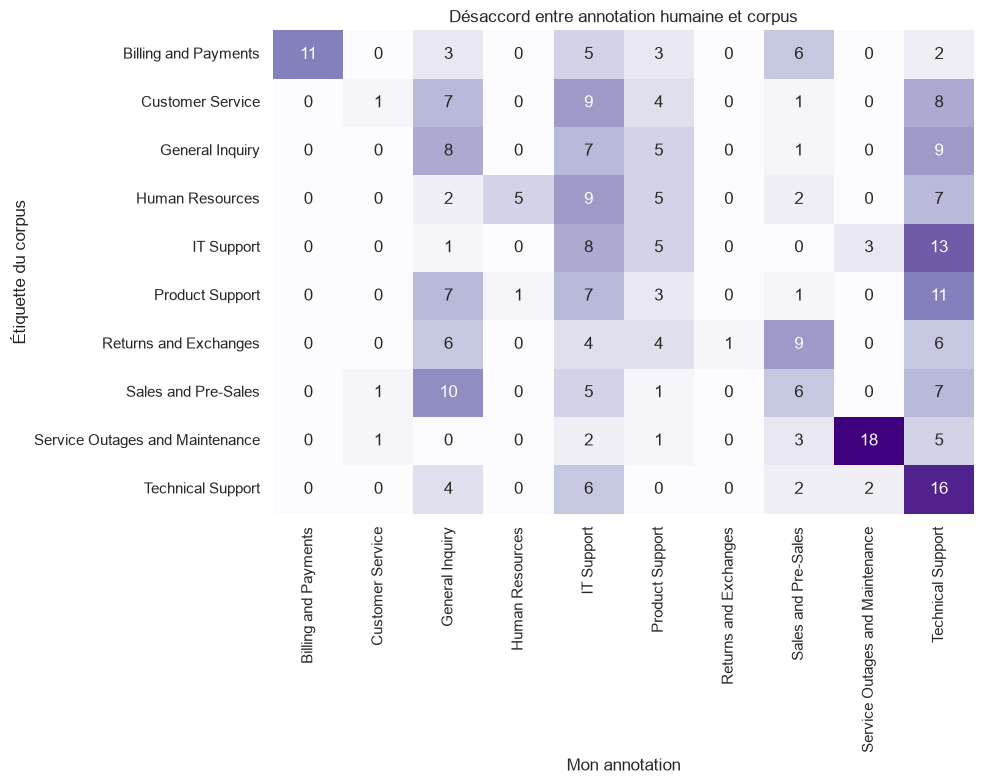

In [4]:
labels = sorted(QUEUES)
cm = pd.crosstab(g["data_queue"], g["human_queue"]).reindex(
    index=labels, columns=labels, fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("Mon annotation"); plt.ylabel("Étiquette du corpus")
plt.title("Désaccord entre annotation humaine et corpus")
plt.tight_layout(); plt.show()

In [5]:
prio_cm = pd.crosstab(g["data_priority"], g["human_priority"],
                      normalize="index").reindex(
    index=["low","medium","high"], columns=["low","medium","high"], fill_value=0)
print("\nPriority — rows = corpus, cols = human:")
print(prio_cm.round(2).to_string())


Priority — rows = corpus, cols = human:
human_priority   low  medium  high
data_priority                     
low             0.42    0.38  0.20
medium          0.40    0.40  0.20
high            0.33    0.23  0.44


In [6]:
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report

vec = joblib.load("../models/tfidf_vectorizer.joblib")
qclf = joblib.load("../models/queue_classifier.joblib")
pclf = joblib.load("../models/priority_classifier.joblib")

X = vec.transform(g["text"])
g["pred_queue"] = qclf.predict(X)
g["pred_priority"] = pclf.predict(X)
g["queue_conf"] = qclf.predict_proba(X).max(axis=1)

rows = []
for task, pred, dat, hum in [
    ("Queue",    "pred_queue",    "data_queue",    "human_queue"),
    ("Priority", "pred_priority", "data_priority", "human_priority"),
]:
    rows.append({
        "Tâche": task,
        "vs corpus (acc)":  accuracy_score(g[dat], g[pred]),
        "vs humain (acc)":  accuracy_score(g[hum], g[pred]),
        "vs corpus (F1)":   f1_score(g[dat], g[pred], average="macro"),
        "vs humain (F1)":   f1_score(g[hum], g[pred], average="macro"),
    })

res = pd.DataFrame(rows)
print(res.round(4).to_string(index=False))

   Tâche  vs corpus (acc)  vs humain (acc)  vs corpus (F1)  vs humain (F1)
   Queue           0.4933           0.2667          0.5179          0.2519
Priority           0.6000           0.3767          0.5655          0.3472


In [7]:
human_high = g["human_priority"] == "high"
caught = human_high & (g["pred_priority"] == "high")

print(f"Tickets jugés critiques par annotation : {human_high.sum()}")
print(f"  détectés par le modèle              : {caught.sum()} "
      f"({caught.sum()/human_high.sum():.3f})")

missed_low = human_high & (g["pred_priority"] == "low")
print(f"  classés en priorité faible          : {missed_low.sum()} "
      f"({missed_low.sum()/human_high.sum():.3f})")

Tickets jugés critiques par annotation : 83
  détectés par le modèle              : 47 (0.566)
  classés en priorité faible          : 4 (0.048)


In [8]:
for lo, hi in [(0, .4), (.4, .5), (.5, .6), (.6, 1.01)]:
    m = (g["queue_conf"] >= lo) & (g["queue_conf"] < hi)
    if m.sum() >= 10:
        print(f"conf [{lo:.1f}, {hi:.1f})  n={m.sum():3d}  "
              f"exact vs humain={accuracy_score(g.loc[m,'human_queue'], g.loc[m,'pred_queue']):.3f}")

conf [0.0, 0.4)  n=153  exact vs humain=0.176
conf [0.4, 0.5)  n= 68  exact vs humain=0.191
conf [0.5, 0.6)  n= 38  exact vs humain=0.421
conf [0.6, 1.0)  n= 41  exact vs humain=0.585


In [9]:
g.to_csv(PROC_DIR / "gold_analysis.csv", index=False)
print("Saved gold_analysis.csv")

Saved gold_analysis.csv


In [10]:
from sklearn.metrics import cohen_kappa_score

print(f"Queue    kappa : {cohen_kappa_score(g['human_queue'], g['data_queue']):.3f}")
print(f"Priority kappa : {cohen_kappa_score(g['human_priority'], g['data_priority']):.3f}")

print("\nRépartition de mes annotations :")
print(g["human_queue"].value_counts().to_string())

Queue    kappa : 0.174
Priority kappa : 0.128

Répartition de mes annotations :
human_queue
Technical Support                  84
IT Support                         62
General Inquiry                    48
Sales and Pre-Sales                31
Product Support                    31
Service Outages and Maintenance    23
Billing and Payments               11
Human Resources                     6
Customer Service                    3
Returns and Exchanges               1


In [11]:
dis = g[~g["queue_agree"]].sample(10, random_state=3)
for _, r in dis.iterrows():
    print("\n" + "="*78)
    print(f"CORPUS: {r['data_queue']}   |   MOI: {r['human_queue']}   |   MODÈLE: {r['pred_queue']}")
    print(r["text"][:400])


CORPUS: Product Support   |   MOI: Technical Support   |   MODÈLE: Product Support
problem encountered while updating dashboards the data analytics dashboards experienced an update failure due to a misconfigured hdmi cable after restarting the system and inspecting the connections the issue still exists

CORPUS: General Inquiry   |   MOI: IT Support   |   MODÈLE: Technical Support
security protocols for laptops storing sensitive medical data respected customer support i am reaching out to request guidance on the necessary security protocols for safeguarding medical data on portable computers given the critical nature of medical data it is imperative to maintain its confidentiality integrity and accessibility could you please advise on the encryption techniques and restricte

CORPUS: Returns and Exchanges   |   MOI: IT Support   |   MODÈLE: Technical Support
notify about security breach event an unauthorized access attempt on systems might have exposed medical data due to outdated soft

In [12]:
dis = g[~g["queue_agree"]].sample(30, random_state=11)
dis[["text", "data_queue", "human_queue", "pred_queue"]].to_csv(
    PROC_DIR / "disagreement_review.csv", index=False, encoding="utf-8-sig")
print("30 cases exported for classification")

30 cases exported for classification


In [14]:
dis = g[~g["queue_agree"]].sample(30, random_state=11).copy()
dis["case"] = ""   # to fill in manually
dis[["text", "data_queue", "human_queue", "pred_queue", "case"]].to_csv(
    PROC_DIR / "disagreement_review.csv", index=False, encoding="utf-8-sig")
print("Exported — now open the file and fill the 'case' column")

Exported — now open the file and fill the 'case' column


In [16]:
rev = pd.read_csv(PROC_DIR / "disagreement_review.csv", encoding="utf-8-sig")
rev["case"] = rev["case"].fillna("").astype(str).str.strip()

unfilled = (rev["case"] == "").sum()
print(f"Unfilled rows: {unfilled} / {len(rev)}")

if unfilled == 0:
    print()
    print(rev["case"].value_counts().to_string())
    print()
    print(rev["case"].value_counts(normalize=True).round(2).to_string())

Unfilled rows: 30 / 30


In [17]:
rev = pd.read_csv(PROC_DIR / "disagreement_review.csv", encoding="utf-8-sig")
rev["case"] = rev["case"].fillna("").astype(str).str.strip()

print(rev["case"].value_counts().to_string())
print()
print((rev["case"].value_counts(normalize=True) * 100).round(1).to_string())

case
corpus_error    14
ambiguous       14
my_error         2

case
corpus_error    46.7
ambiguous       46.7
my_error         6.7


In [18]:
summary = rev["case"].value_counts().rename("n").to_frame()
summary["pct"] = (rev["case"].value_counts(normalize=True) * 100).round(1)
summary.to_csv(PROC_DIR / "disagreement_summary.csv")
print(summary.to_string())

               n   pct
case                  
corpus_error  14  46.7
ambiguous     14  46.7
my_error       2   6.7
